## Creating/ repurposing a model to try and match distributions of particles observed in IFCB data

This samples from preset normal distribs of particle size and density in ratios determined by the user, these are then palced in a syringe randomly up to a user defined N. The stokes settling speed is added to a background IFCB syringe speed to get a net velocity, The time to bottom is then calculated and saved.

In [17]:
import numpy as np
import pandas as pd


def simulate_particle_settling(
    particle_classes,
    h = 0.110998,  # height of the syringe in meters
    n_particles=1000,
    fluid_density=1025,
    fluid_viscosity=1.05e-3,  # viscosity of seawater at 20°C in Pa·s
    g=9.81,
    dt=0.5,
    background_velocity_m_s=0.00009249833333, # flow rate of 1ml/240s
    seed=None,
):
    rng = np.random.default_rng(seed)

    classes = particle_classes.copy()
    classes["fraction"] = classes["fraction"] / classes["fraction"].sum()

    sampled = classes.sample(
        n=n_particles,
        replace=True,
        weights="fraction",
        random_state=seed,
    ).reset_index(drop=True)

    sampled["particle_id"] = np.arange(n_particles)

    sampled["initial_position_m"] = rng.uniform(0, h, n_particles)

    sampled["diameter_m"] = rng.normal(
        sampled["mean_diameter_m"],
        sampled["sd_diameter_m"],
    )

    sampled["density_kg_m3"] = rng.normal(
        sampled["mean_density_kg_m3"],
        sampled["sd_density_kg_m3"],
    )

    # Prevent impossible values
    sampled["diameter_m"] = sampled["diameter_m"].clip(lower=1e-6)
    sampled["density_kg_m3"] = sampled["density_kg_m3"].clip(
        lower=fluid_density + 1
    )

    radius_m = sampled["diameter_m"] / 2

    sampled["settling_velocity_m_s"] = (
        (2 / 9)
        * (sampled["density_kg_m3"] - fluid_density)
        * g
        * radius_m**2
        / fluid_viscosity
    )

    sampled["background_velocity_m_s"] = background_velocity_m_s

    sampled["net_velocity_m_s"] = (
        sampled["settling_velocity_m_s"]
        + sampled["background_velocity_m_s"]
    )

    sampled["time_to_bottom_s"] = np.where(
        sampled["net_velocity_m_s"] > 0,
        sampled["initial_position_m"] / sampled["net_velocity_m_s"],
        np.inf,
    )

    sampled["arrival_timestep"] = np.where(
        np.isfinite(sampled["time_to_bottom_s"]),
        np.ceil(sampled["time_to_bottom_s"] / dt).astype(int),
        -1,
    )

    results = sampled[
        [
            "particle_id",
            "size_class",
            "diameter_m",
            "density_kg_m3",
            "initial_position_m",
            "settling_velocity_m_s",
            "background_velocity_m_s",
            "net_velocity_m_s",
            "time_to_bottom_s",
            "arrival_timestep",
        ]
    ]

    return results



In [21]:

# -------------------------
# Example particle classes
# -------------------------

particle_classes = pd.DataFrame({
    "size_class": [
        "cryptophyte",
        "dinoflagellate",
        "shellfish_larva",
    ],

    "mean_diameter_m": [
        10e-6,
        50e-6,
        100e-6,
    ],

    "sd_diameter_m": [
        3e-6,
        15e-6,
        25e-6,
    ],

    "mean_density_kg_m3": [
        1050,
        1100,
        1200,
    ],

    "sd_density_kg_m3": [
        10,
        25,
        50,
    ],

    "fraction": [
        0.4,
        0.4,
        0.2,
    ],
})


# -------------------------
# Run simulation
# -------------------------

df = simulate_particle_settling(
    particle_classes=particle_classes,
    n_particles=25000,
    fluid_density=1025,        # seawater density, kg/m^3
    fluid_viscosity=1.05e-3,     # water viscosity, Pa*s
    dt=0.5,                     # timestep, s
    background_velocity_m_s=0.00009249833333, # flow rate of 1ml/240s,
    seed=42,
)


print(df.head())
print(df.groupby("size_class")["time_to_bottom_s"].describe())


   particle_id       size_class  diameter_m  density_kg_m3  \
0            0      cryptophyte    0.000007    1026.000000   
1            1  shellfish_larva    0.000085    1214.037640   
2            2   dinoflagellate    0.000058    1081.318984   
3            3   dinoflagellate    0.000050    1099.415764   
4            4      cryptophyte    0.000009    1058.321851   

   initial_position_m  settling_velocity_m_s  background_velocity_m_s  \
0            0.085908           2.497590e-08                 0.000092   
1            0.048715           7.072329e-04                 0.000092   
2            0.095303           9.836785e-05                 0.000092   
3            0.077406           9.518724e-05                 0.000092   
4            0.010453           1.269799e-06                 0.000092   

   net_velocity_m_s  time_to_bottom_s  arrival_timestep  
0          0.000093        928.496551              1857  
1          0.000800         60.913750               122  
2          0.0

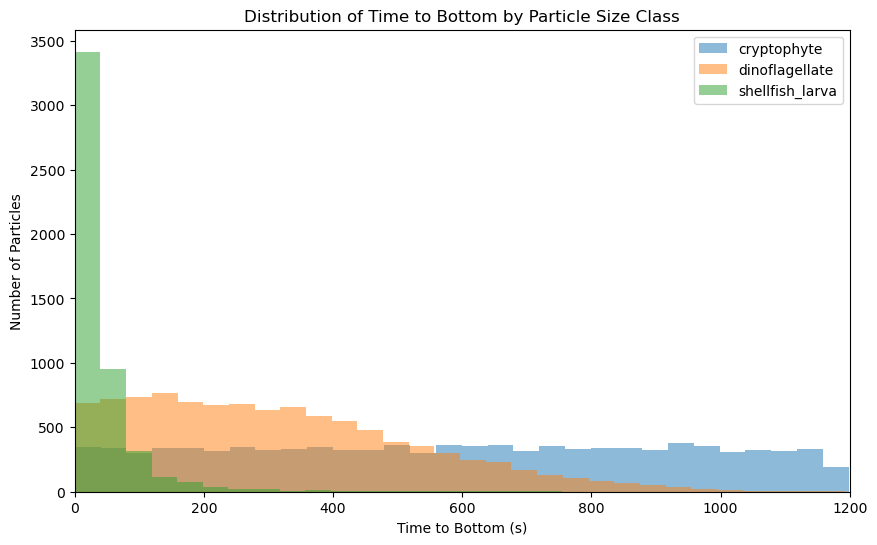

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for size_class in particle_classes["size_class"]:
    subset = df[df["size_class"] == size_class]
    plt.hist(subset["time_to_bottom_s"], bins=30, alpha=0.5, label=size_class)
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.xlabel("Time to Bottom (s)")
plt.ylabel("Number of Particles")
plt.title("Distribution of Time to Bottom by Particle Size Class")
plt.legend()
plt.show()

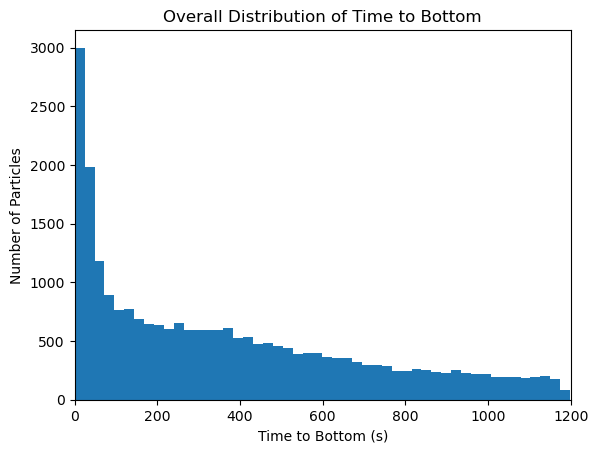

In [20]:
plt.hist(df["time_to_bottom_s"], bins=50)
plt.xlabel("Time to Bottom (s)")
plt.ylabel("Number of Particles")
plt.title("Overall Distribution of Time to Bottom")
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.show()

In [13]:
particle_classes.head()

,size_class,diameter_m,density_kg_m3,fraction
0,cryptophyte,0.00001,1050,0.4
1,dinoflagellate,0.00005,1100,0.4
2,shellfish_larva,0.00015,1200,0.2


## Trying to use simulated IFCB sampling to see what the distribution then looks like after it has been sampled by IFCB with inhibit time issues

In [22]:
import numpy as np
import pandas as pd

def simulate_ifcb_sampling(arrival_times, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    arrival_times : array-like
        Sorted or unsorted underlying particle arrival times in seconds.
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """

    arrival_times = np.sort(np.asarray(arrival_times))

    sampled_flags = []
    next_available_time = 0

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
        else:
            sampled_flags.append(False)

    df = pd.DataFrame({
        "arrival_time": arrival_times,
        "sampled": sampled_flags
          })

    return df

In [23]:
arrival_times = df["time_to_bottom_s"].values
sampling_results = simulate_ifcb_sampling(arrival_times, inhibit_time=0.08)

In [24]:
merged_df = df.merge(sampling_results, left_on="time_to_bottom_s", right_on="arrival_time", how="left")

In [25]:
print(merged_df.head())

   particle_id       size_class  diameter_m  density_kg_m3  \
0            0      cryptophyte    0.000007    1026.000000   
1            1  shellfish_larva    0.000085    1214.037640   
2            2   dinoflagellate    0.000058    1081.318984   
3            3   dinoflagellate    0.000050    1099.415764   
4            4      cryptophyte    0.000009    1058.321851   

   initial_position_m  settling_velocity_m_s  background_velocity_m_s  \
0            0.085908           2.497590e-08                 0.000092   
1            0.048715           7.072329e-04                 0.000092   
2            0.095303           9.836785e-05                 0.000092   
3            0.077406           9.518724e-05                 0.000092   
4            0.010453           1.269799e-06                 0.000092   

   net_velocity_m_s  time_to_bottom_s  arrival_timestep  arrival_time  sampled  
0          0.000093        928.496551              1857    928.496551     True  
1          0.000800       

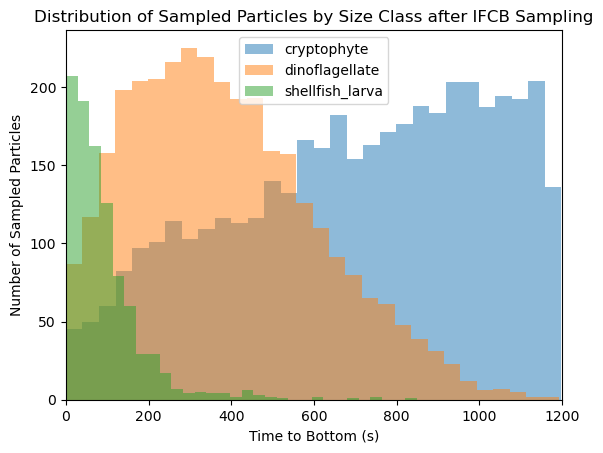

In [27]:
sampled_df = merged_df[merged_df["sampled"] == True]
for size_class in particle_classes["size_class"]:
    subset = sampled_df[sampled_df["size_class"] == size_class]
    plt.hist(subset["time_to_bottom_s"], bins=30, alpha=0.5, label=size_class)
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.xlabel("Time to Bottom (s)")
plt.ylabel("Number of Sampled Particles")
plt.title("Distribution of Sampled Particles by Size Class after IFCB Sampling")
plt.legend()
plt.show()

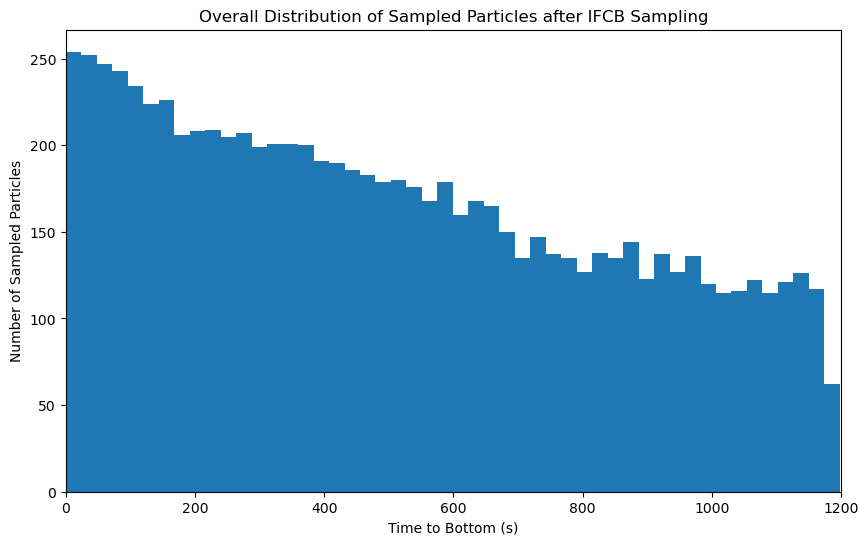

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(sampled_df["time_to_bottom_s"], bins=50)
plt.xlabel("Time to Bottom (s)")
plt.ylabel("Number of Sampled Particles")
plt.title("Overall Distribution of Sampled Particles after IFCB Sampling")
plt.xlim(0, 1200)  # Limit x-axis for better visualization
plt.show()

In [29]:
particle_classes

,size_class,mean_diameter_m,sd_diameter_m,mean_density_kg_m3,sd_density_kg_m3,fraction
0,cryptophyte,0.00001,0.000003,1050,10,0.4
1,dinoflagellate,0.00005,0.000015,1100,25,0.4
2,shellfish_larva,0.00010,0.000025,1200,50,0.2
